# Week 2 Lab (Part 1): Matching Law

This lab explores the Generalized Matching Equation (GME) using data from ten
hypothetical participants. The GME in log-ratio form is:

$$\log\left(\frac{B_1}{B_2}\right) = a \cdot \log\left(\frac{R_1}{R_2}\right) + \log b$$

- $B_1/B_2$: response ratio
- $R_1/R_2$: reinforcer ratio
- $a$: sensitivity (slope)
- $\log b$: bias (intercept)

Your job, as a researcher would: fit the GME to each participant, then look for
group-level trends. Code cells are blank for you to fill in.

## Setup and load the data

Import your libraries, then load all ten participant files (`gme_data_P01.csv` ... `gme_data_P10.csv`) into a dictionary keyed by participant id. The files sit in this notebook's folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import os

sns.set(style="whitegrid")
data_dir = "."
file_paths = [os.path.join(data_dir, f"gme_data_P{str(i).zfill(2)}.csv") for i in range(1, 11)]
participant_data = {}

for path in file_paths:
    pid = os.path.basename(path).split("_")[-1].split(".")[0]
    participant_data[pid] = pd.read_csv(path)

participant_data

{'P01':       condition  session   b1   b2  r1  r2  schedule_r1  schedule_r2  PID
 0             1        1  117  354   1   4            1            9  P01
 1             1        2  122  769   1   5            1            9  P01
 2             1        3   28  876   1   8            1            9  P01
 3             1        4  229  205   1   9            1            9  P01
 4             1        5   29  423   1   3            1            9  P01
 ...         ...      ...  ...  ...  ..  ..          ...          ...  ...
 4995          5      996  366  195   7   1            9            1  P01
 4996          5      997  497    5   6   1            9            1  P01
 4997          5      998  642  166   9   1            9            1  P01
 4998          5      999  834   38  10   1            9            1  P01
 4999          5     1000  940   10   7   1            9            1  P01
 
 [5000 rows x 9 columns],
 'P02':       condition  session   b1   b2  r1  r2  schedule_r1  

## Task 1: Combine the data and compute log ratios

Concatenate all participants into one DataFrame. Add 1 to every behavior and reinforcer count to avoid `log(0)`, then compute the log response ratio and log reinforcer ratio.

In [2]:
all_data = pd.concat(participant_data.values(), ignore_index=True)

# Add 1 to all counts to avoid log(0)
for col in ['b1', 'b2', 'r1', 'r2']:
    all_data[col] = all_data[col] + 1

all_data['log_response_ratio'] = np.log(all_data['b1'] / all_data['b2'])
all_data['log_reinforcer_ratio'] = np.log(all_data['r1'] / all_data['r2'])
all_data

,condition,session,b1,b2,r1,r2,schedule_r1,schedule_r2,PID,log_response_ratio,log_reinforcer_ratio
0,1,1,118,355,2,5,1,9,P01,-1.101433,-0.916291
1,1,2,123,770,2,6,1,9,P01,-1.834206,-1.098612
2,1,3,29,877,2,9,1,9,P01,-3.409211,-1.504077
3,1,4,230,206,2,10,1,9,P01,0.110203,-1.609438
4,1,5,30,424,2,4,1,9,P01,-2.648536,-0.693147
...,...,...,...,...,...,...,...,...,...,...,...
49995,5,996,390,304,5,3,9,1,P10,0.249119,0.510826
49996,5,997,382,509,2,2,9,1,P10,-0.287027,0.000000
49997,5,998,244,268,8,2,9,1,P10,-0.093819,1.386294
49998,5,999,353,596,3,2,9,1,P10,-0.523773,0.405465


## Task 2: Fit the GME for each participant

For each participant, regress the log response ratio on the log reinforcer ratio with `scipy.stats.linregress`. Record sensitivity (slope), bias (intercept), and R-squared, and plot each participant's data with the fitted line and the perfect-matching line.

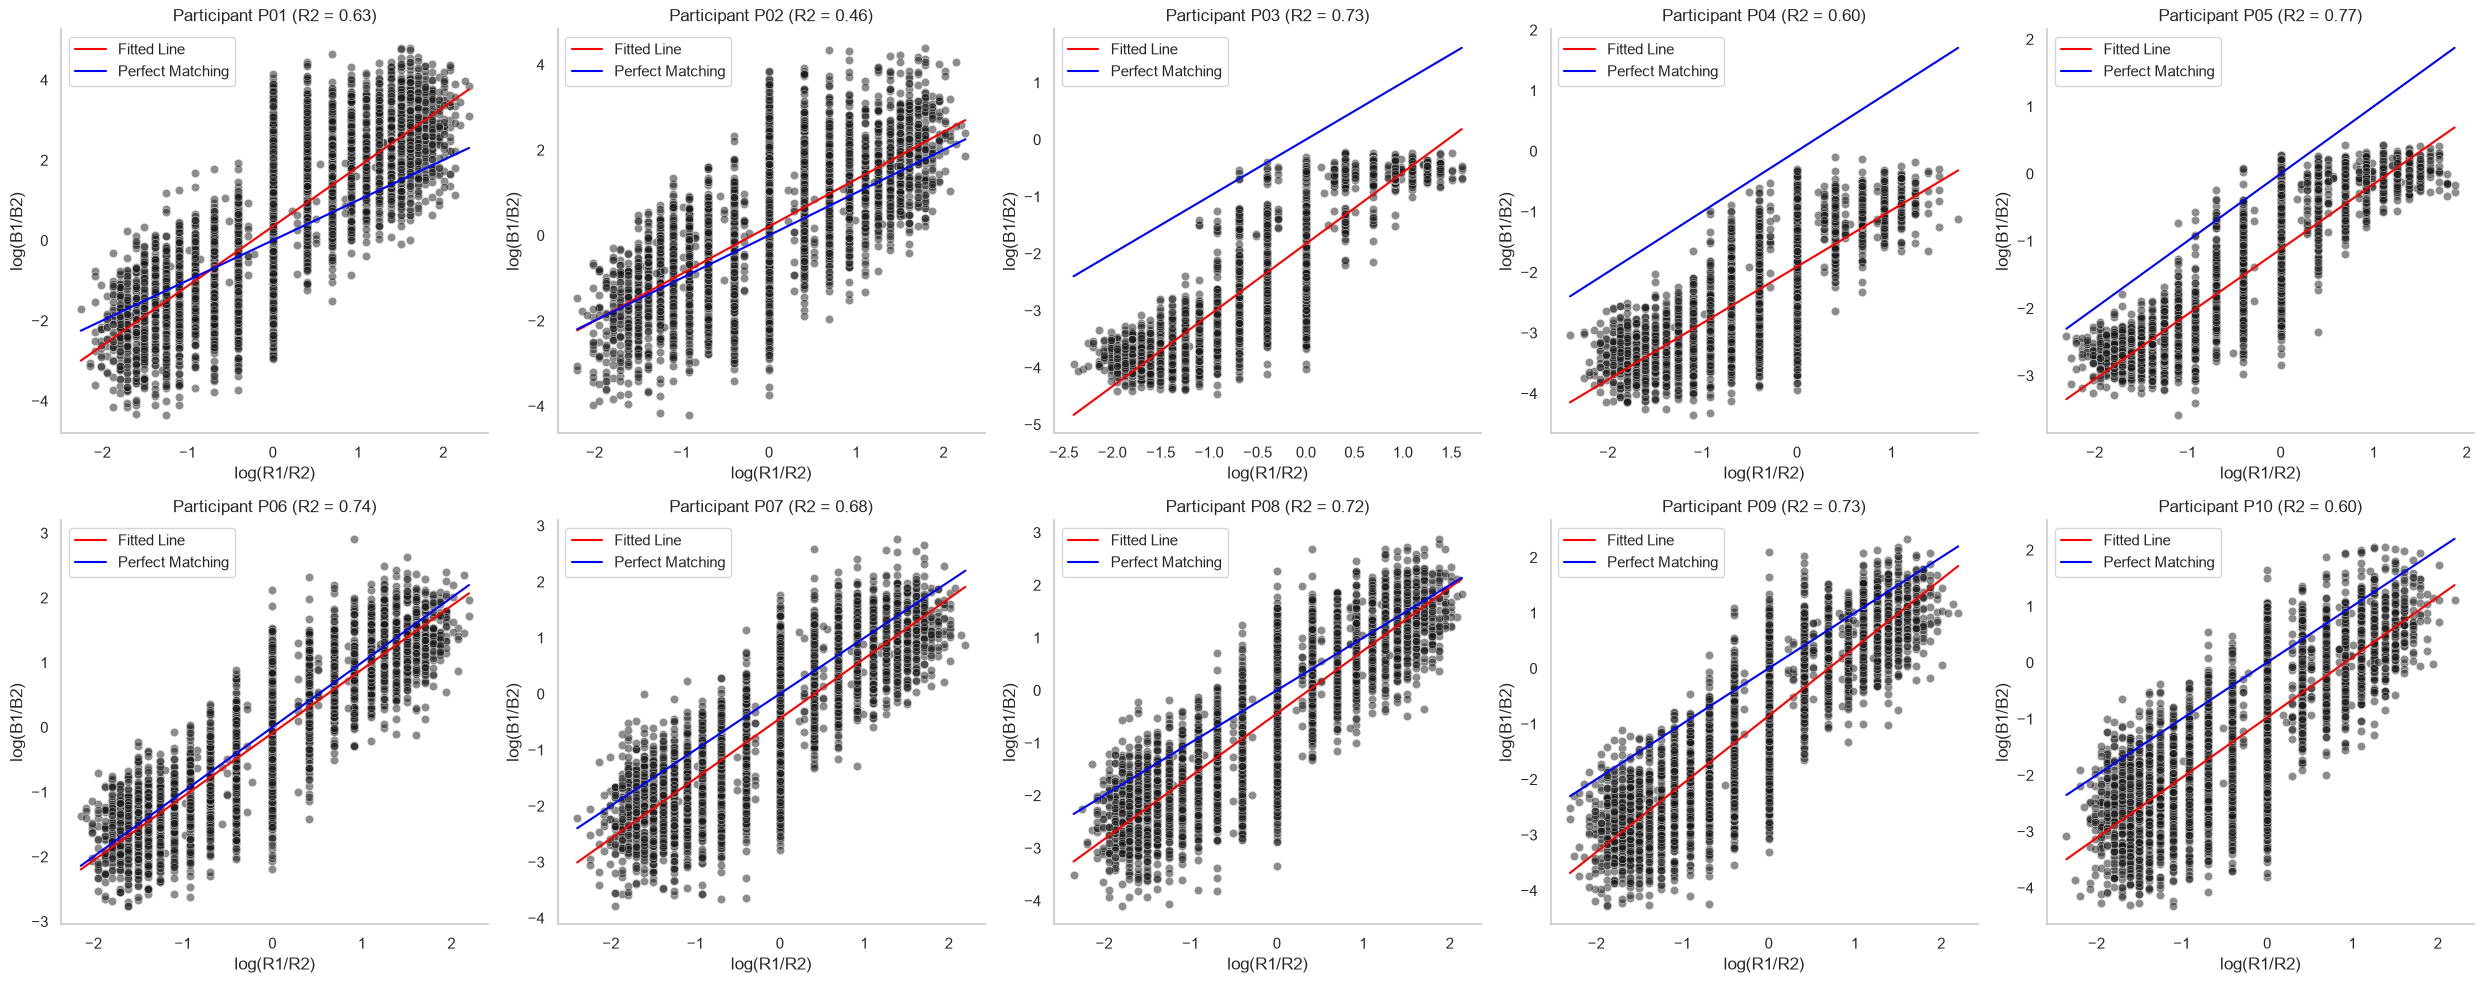

In [3]:
results = []
plt.figure(figsize=(25, 10))
participants = all_data['PID'].unique()

for idx, pid in enumerate(participants, 1):
    df = all_data[all_data['PID'] == pid]
    df = df.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['log_response_ratio', 'log_reinforcer_ratio'])

    slope, intercept, r_value, p_value, std_err = linregress(
        df['log_reinforcer_ratio'], df['log_response_ratio'])
    results.append({"Participant": pid, "Sensitivity (a)": slope,
                    "Bias (log b)": intercept, "R-squared": r_value ** 2})

    plt.subplot(2, 5, idx)
    sns.scatterplot(x='log_reinforcer_ratio', y='log_response_ratio', data=df, color='k', alpha=0.5)
    x_vals = np.linspace(df['log_reinforcer_ratio'].min(), df['log_reinforcer_ratio'].max(), 100)
    plt.plot(x_vals, slope * x_vals + intercept, color='red', label='Fitted Line')
    plt.plot(x_vals, x_vals, color='blue', label='Perfect Matching')
    plt.title(f'Participant {pid} (R2 = {r_value**2:.2f})')
    plt.grid(False)
    plt.xlabel('log(R1/R2)'); plt.ylabel('log(B1/B2)')
    sns.despine(top=True, right=True)
    plt.legend()

plt.tight_layout()
plt.show()

## Task 3: Build the group summary table

Collect the per-participant parameters into a tidy summary table sorted by participant.

In [4]:
summary_df = pd.DataFrame(results).sort_values("Participant").reset_index(drop=True)
summary_df

,Participant,Sensitivity (a),Bias (log b),R-squared
0,P01,1.484732,0.344608,0.630622
1,P02,1.107423,0.207008,0.456878
2,P03,1.251214,-1.829435,0.725845
3,P04,0.933123,-1.909321,0.604527
4,P05,0.967355,-1.121724,0.765613
5,P06,0.983323,-0.091305,0.735928
6,P07,1.069910,-0.441590,0.682135
7,P08,1.196271,-0.442340,0.721014
8,P09,1.228687,-0.855913,0.725733
9,P10,1.070273,-0.976483,0.601230


## Task 4: Visualize the group-level parameters

Plot the distribution of sensitivity, bias, and R-squared across participants (a bar plot with the individual points overlaid works well).

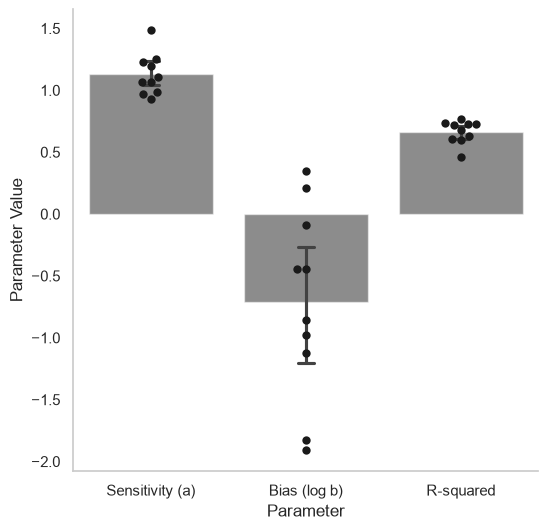

In [5]:
summary_df_long = summary_df.melt(id_vars=['Participant'], var_name='Parameter', value_name='Value')

plt.figure(figsize=(6, 6))
sns.barplot(x='Parameter', y='Value', data=summary_df_long, color='k', alpha=0.5, capsize=0.1)
sns.swarmplot(x='Parameter', y='Value', data=summary_df_long, color='k', size=6)
plt.xlabel('Parameter'); plt.ylabel('Parameter Value')
plt.grid(False)
sns.despine(top=True, right=True)
plt.show()

## Wrap-up

Interpret your results: Are participants matching, undermatching, or overmatching (what do the sensitivity values say)? Is there systematic bias? How well does the GME describe these data overall?